Se encontraron 4 siluetas de coches.


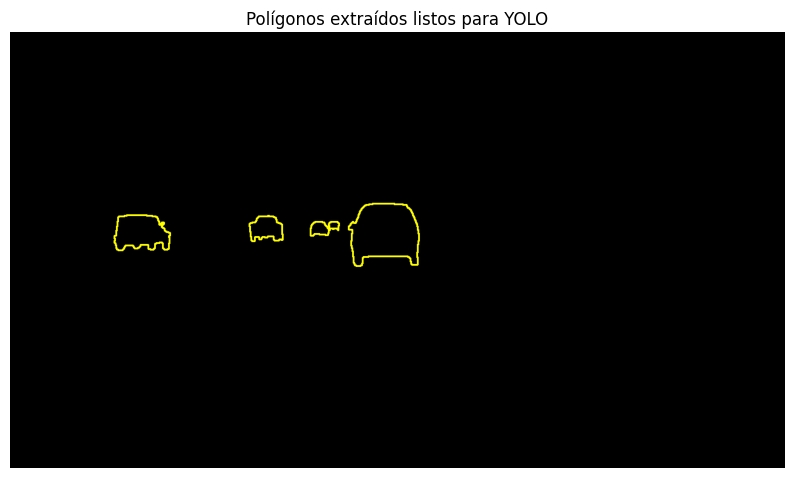

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Ruta a la imagen negra (train_ids) que subiste
ruta_mascara_id = '../data/segmentacion/labels/train/0a0a0b1a-7c39d841_train_id.png'

# 2. Cargar la imagen en modo escala de grises (MUY IMPORTANTE)
mascara = cv2.imread(ruta_mascara_id, cv2.IMREAD_GRAYSCALE)
alto, ancho = mascara.shape

# 3. En el dataset BDD100K, el ID del coche ("car") suele ser el número 13
id_coche = 13 

# Crear una imagen binaria temporal: Blanco donde haya coches, Negro lo demás
_, mascara_coches = cv2.threshold(mascara, id_coche - 1, 255, cv2.THRESH_BINARY)
_, mascara_coches_exacta = cv2.threshold(mascara, id_coche, 255, cv2.THRESH_BINARY_INV)
mascara_binaria = cv2.bitwise_and(mascara_coches, mascara_coches_exacta)

# 4. Encontrar los contornos (siluetas) usando OpenCV
contornos, _ = cv2.findContours(mascara_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Se encontraron {len(contornos)} siluetas de coches.")

# 5. Visualizar el resultado para confirmar que extrajimos los polígonos
imagen_visual = np.zeros((alto, ancho, 3), dtype=np.uint8)
cv2.drawContours(imagen_visual, contornos, -1, (0, 255, 255), 2) # Dibujar en amarillo

plt.figure(figsize=(10, 6))
plt.title("Polígonos extraídos listos para YOLO")
plt.imshow(cv2.cvtColor(imagen_visual, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# 6. Ejemplo de cómo se guardaría en un TXT para YOLO (Clase 0 = Vehiculo)
# YOLO usa formato: clase x1 y1 x2 y2 x3 y3 ... (normalizado de 0 a 1)
for contorno in contornos:
    if cv2.contourArea(contorno) > 100: # Ignorar manchas de polvo de 2 píxeles
        linea_yolo = "0 " # Asumiendo que Vehículo es tu clase 0
        for punto in contorno:
            x_norm = punto[0][0] / ancho
            y_norm = punto[0][1] / alto
            linea_yolo += f"{x_norm:.5f} {y_norm:.5f} "
        
        # Al imprimir esto, verás el formato exacto que YOLO necesita en su .txt
        # print(linea_yolo[:100] + "...")